# 02- Data Preprocessing

### 1: Mounting drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


### 2: Seeds and Configuration

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SUBSET_TRAIN = 4000
SUBSET_VAL   = 500
SUBSET_TEST  = 500
IMG_SIZE     = (224, 224)

print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Train: {SUBSET_TRAIN} | Val: {SUBSET_VAL} | Test: {SUBSET_TEST}")

Seed: 42 | Device: cuda
Train: 4000 | Val: 500 | Test: 500


### 3: Installing Required Packages

In [ ]:
!pip install datasets==2.14.6 --quiet
!pip install transformers==4.40.0 --quiet
!pip install torch torchvision --quiet
!apt-get install -y tesseract-ocr tesseract-ocr-eng --quiet
!pip install pytesseract pillow opencv-python-headless --quiet
!pip install scikit-learn pandas matplotlib seaborn tqdm --quiet
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 17.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6

### 4: Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
import cv2
import json
import torch
import torchvision.transforms as T
from collections import Counter

print("All imports are fine.")

All imports ok


### 5: Load Dataset

In [ ]:
from datasets import load_dataset

print("Loading RVL-CDIP")

train_ds = load_dataset("rvl_cdip", split="train", streaming=True)
val_ds   = load_dataset("rvl_cdip", split="validation", streaming=True)
test_ds  = load_dataset("rvl_cdip", split="test", streaming=True)

train_list = list(train_ds.take(SUBSET_TRAIN))
val_list   = list(val_ds.take(SUBSET_VAL))
test_list  = list(test_ds.take(SUBSET_TEST))

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']
NUM_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(train_list)} | Val: {len(val_list)} | Test: {len(test_list)}")
print(f"Classes: {NUM_CLASSES}")

Loading RVL-CDIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train: 4000 | Val: 500 | Test: 500
Classes: 16


### 6: OCR Pipeline Preprocessing

In [ ]:
def preprocess_for_ocr(pil_img, target_size=IMG_SIZE):
    """
    Preprocessing pipeline for OCR baseline
    Steps: converting to grayscale → denoise → resize
    """
    #Step 1 — converting to grayscale
    gray = pil_img.convert('L')

    #Step 2 — denoising using median filter
    denoised = gray.filter(ImageFilter.MedianFilter(size=3))

    #Step 3 — resizing to standard size
    resized = denoised.resize(target_size, Image.LANCZOS)

    return resized


#Testing on a sample
sample_img = train_list[0]['image']
processed_ocr = preprocess_for_ocr(sample_img)

print(f"Original size  : {sample_img.size} | Mode: {sample_img.mode}")
print(f"Processed size : {processed_ocr.size} | Mode: {processed_ocr.mode}")

Original size  : (762, 1000) | Mode: L
Processed size : (224, 224) | Mode: L


### 7: VLM Pipeline Preprocessing

In [ ]:
def preprocess_for_vlm(pil_img, target_size=IMG_SIZE):
    """
    Preprocessing pipeline for VLM pipeline
    Steps: converting to RGB → resize → normalize
    """
    #Step 1 — ensuring RGB
    rgb = pil_img.convert('RGB')

    #Step 2 — resizing
    resized = rgb.resize(target_size, Image.LANCZOS)

    return resized


#VLM also needs tensor transform for model input
vlm_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

#Testing on a sample
processed_vlm = preprocess_for_vlm(sample_img)
tensor = vlm_transform(processed_vlm)

print(f"Original size  : {sample_img.size} | Mode: {sample_img.mode}")
print(f"Processed size : {processed_vlm.size} | Mode: {processed_vlm.mode}")
print(f"Tensor shape   : {tensor.shape}")
print(f"Tensor min/max : {tensor.min():.3f} / {tensor.max():.3f}")

Original size  : (762, 1000) | Mode: L
Processed size : (224, 224) | Mode: RGB
Tensor shape   : torch.Size([3, 224, 224])
Tensor min/max : -2.118 / 2.640


### 8: Visual Comparison — Before and After Preprocessing

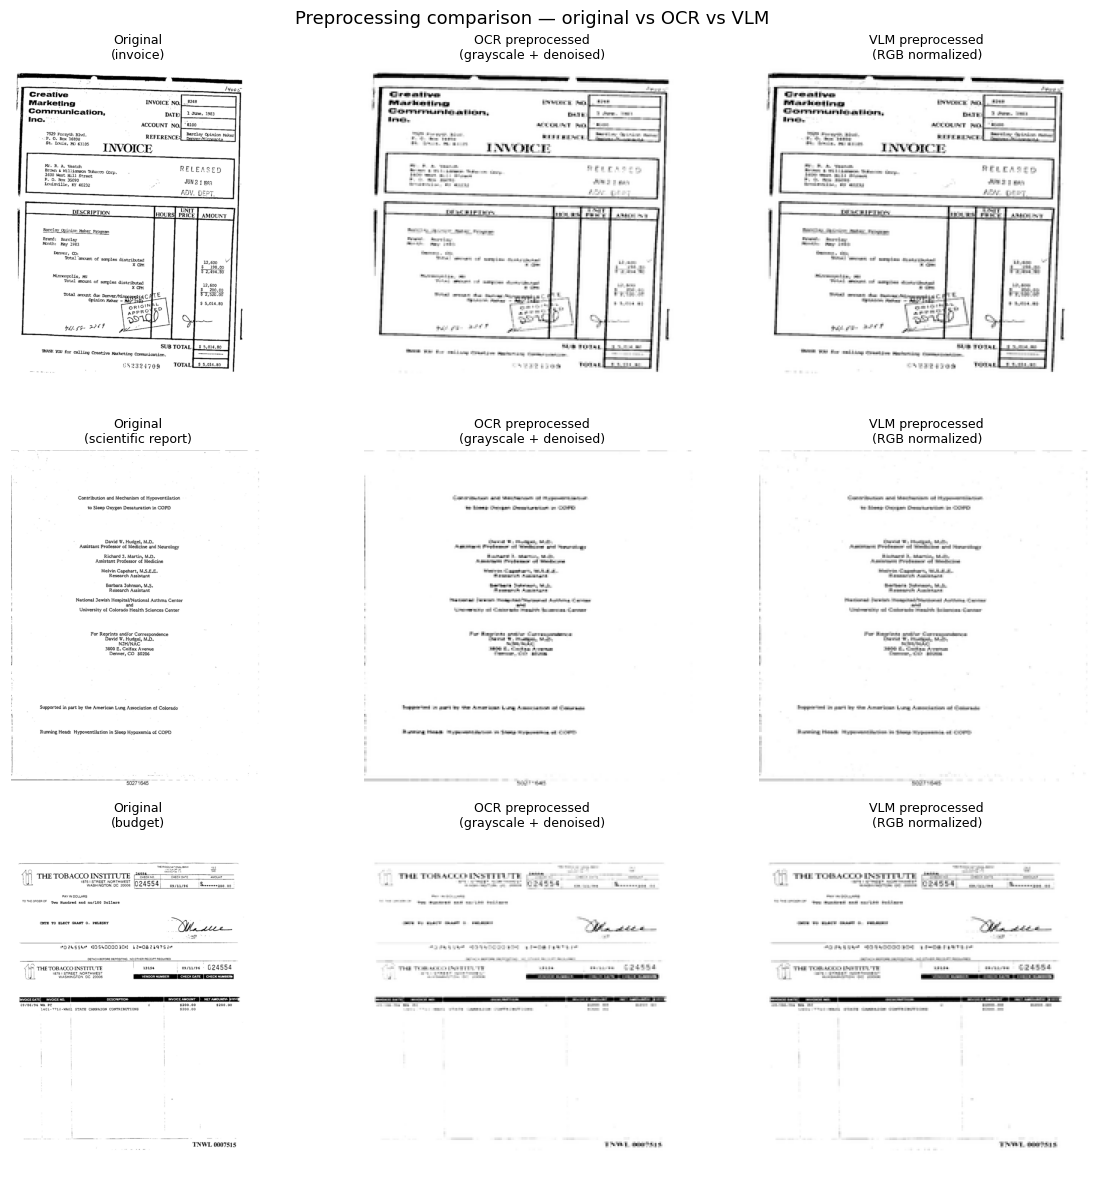

Preprocessing comparison saved.


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

samples_to_show = [0, 100, 200]

for row, idx in enumerate(samples_to_show):
    original  = train_list[idx]['image']
    ocr_proc  = preprocess_for_ocr(original)
    vlm_proc  = preprocess_for_vlm(original)
    label     = LABEL_NAMES[train_list[idx]['label']]

    axes[row][0].imshow(original, cmap='gray')
    axes[row][0].set_title(f"Original\n({label})", fontsize=9)
    axes[row][0].axis('off')

    axes[row][1].imshow(ocr_proc, cmap='gray')
    axes[row][1].set_title(f"OCR preprocessed\n(grayscale + denoised)", fontsize=9)
    axes[row][1].axis('off')

    axes[row][2].imshow(vlm_proc)
    axes[row][2].set_title(f"VLM preprocessed\n(RGB normalized)", fontsize=9)
    axes[row][2].axis('off')

plt.suptitle("Preprocessing comparison — original vs OCR vs VLM", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/preprocessing_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Preprocessing comparison saved.")

### 9: Save Fixed Train/Val/Test Splits

In [ ]:
import json

#Fixed splits ensures that all notebooks use identical data partitions
#Required for fair comparison between baseline and improved method

splits = {
    "train" : list(range(SUBSET_TRAIN)),
    "val"   : list(range(SUBSET_VAL)),
    "test"  : list(range(SUBSET_TEST)),
    "ratios": {
        "train": f"{SUBSET_TRAIN/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%",
        "val"  : f"{SUBSET_VAL/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%",
        "test" : f"{SUBSET_TEST/(SUBSET_TRAIN+SUBSET_VAL+SUBSET_TEST)*100:.0f}%"
    }
}

split_path = f"{BASE}/data/splits.json"
with open(split_path, "w") as f:
    json.dump(splits, f, indent=2)

print("Splits saved:")
print(f"  Train : {SUBSET_TRAIN} samples ({splits['ratios']['train']})")
print(f"  Val   : {SUBSET_VAL} samples ({splits['ratios']['val']})")
print(f"  Test  : {SUBSET_TEST} samples ({splits['ratios']['test']})")
print(f"Saved to: {split_path}")

Splits saved:
  Train : 4000 samples (80%)
  Val   : 500 samples (10%)
  Test  : 500 samples (10%)
Saved to: /content/drive/MyDrive/capstone/data/splits.json


### 10: Verification — All Splits

In [ ]:
print("Verifying preprocessing on all splits")

errors = []

for split_name, split_data in [("train", train_list[:50]),
                                ("val",   val_list[:20]),
                                ("test",  test_list[:20])]:
    for i, item in enumerate(split_data):
        try:
            ocr_img = preprocess_for_ocr(item['image'])
            vlm_img = preprocess_for_vlm(item['image'])
            tensor  = vlm_transform(vlm_img)

            assert ocr_img.size == IMG_SIZE, "OCR size mismatch"
            assert vlm_img.size == IMG_SIZE, "VLM size mismatch"
            assert tensor.shape == (3, 224, 224), "Tensor shape mismatch"

        except Exception as e:
            errors.append(f"{split_name}[{i}]: {e}")

if errors:
    print(f"Errors found: {len(errors)}")
    for err in errors:
        print(f"  {err}")
else:
    print("All samples preprocessed successfully, no errors found.")
    print(f"  OCR output : grayscale, {IMG_SIZE}")
    print(f"  VLM output : RGB, {IMG_SIZE}, tensor shape (3, 224, 224)")

Verifying preprocessing on all splits
All samples preprocessed successfully, no errors found.
  OCR output : grayscale, (224, 224)
  VLM output : RGB, (224, 224), tensor shape (3, 224, 224)


### 11: Save Preprocessing Summary

In [ ]:
summary = {
    "ocr_pipeline": {
        "steps"      : ["convert to grayscale", "median filter denoising",
                        "resize to 224x224"],
        "output_mode": "L (grayscale)",
        "output_size": "224x224"
    },
    "vlm_pipeline": {
        "steps"      : ["convert to RGB", "resize to 224x224",
                        "normalize (mean=[0.485,0.456,0.406], "
                        "std=[0.229,0.224,0.225])"],
        "output_mode": "RGB",
        "output_size": "224x224",
        "tensor_shape": "3x224x224"
    },
    "split_ratios": splits['ratios'],
    "random_seed" : SEED,
    "total_samples": SUBSET_TRAIN + SUBSET_VAL + SUBSET_TEST
}

summary_path = f"{BASE}/outputs/results/preprocessing_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Preprocessing summary saved.")
print(json.dumps(summary, indent=2))

Preprocessing summary saved.
{
  "ocr_pipeline": {
    "steps": [
      "convert to grayscale",
      "median filter denoising",
      "resize to 224x224"
    ],
    "output_mode": "L (grayscale)",
    "output_size": "224x224"
  },
  "vlm_pipeline": {
    "steps": [
      "convert to RGB",
      "resize to 224x224",
      "normalize (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])"
    ],
    "output_mode": "RGB",
    "output_size": "224x224",
    "tensor_shape": "3x224x224"
  },
  "split_ratios": {
    "train": "80%",
    "val": "10%",
    "test": "10%"
  },
  "random_seed": 42,
  "total_samples": 5000
}
